In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# data
data = pd.read_csv('laser_power_density.csv')
data_561 = data[data['laser'] == '561nm']
data_488 = data[data['laser'] == '488nm']
data_561.head()

,laser,Intensity (%),mean (mW),std (mW),area (cm^2),density (mW/cm^2),std density (mW/cm^2)
0,561nm,5,1.281250,0.046754,0.000325,3939.361411,143.750981
1,561nm,10,2.126667,0.034480,0.000325,6538.699395,106.013844
2,561nm,20,3.523333,0.104030,0.000325,10832.923610,319.852811
3,561nm,50,7.161429,0.079360,0.000325,22018.696870,244.001148
4,561nm,100,13.216667,0.037268,0.000325,40636.274450,114.584454


Power density at 5% intensity (561nm): 3939.36 mW/cm^2
Power density at 10% intensity (561nm): 6538.7 mW/cm^2
Power density at 20% intensity (561nm): 10832.92 mW/cm^2
Power density at 100% intensity (561nm): 40636.27 mW/cm^2
Power density at 5% intensity (488nm): 2252.46 mW/cm^2
Power density at 10% intensity (488nm): 4076.58 mW/cm^2
Power density at 20% intensity (488nm): 7169.8 mW/cm^2
Power density at 100% intensity (488nm): 31290.25 mW/cm^2


[Text(0, 0, '0'), Text(0, 20000, '2'), Text(0, 40000, '4')]

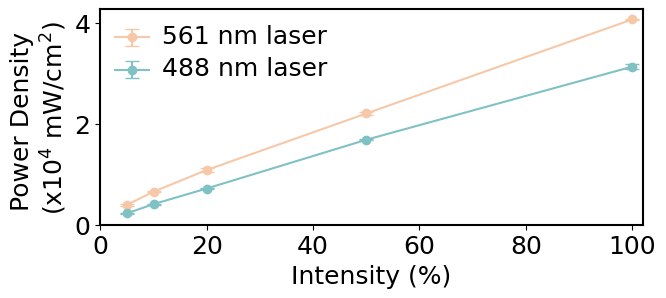

In [3]:
# colors = ['#E89DA0', '#88CEE6', '#F6C8A8', '#B2D3A4', '#9FBA95', '#E6CECF', '#B696B6', '#80C1C4']
color_orange = '#F6C8A8' # for TIRF561
color_cyan = '#80C1C4' # for TIRF488
colors = [color_orange, color_cyan]
# plot density vs. intensity; intensity 2nd column, density 6th column, std 7th column
# plt.figure(figsize=(7, 3.8))
plt.figure(figsize=(7, 2.8))
# plt.plot(data_561.iloc[:,1], data_561.iloc[:,5], 'ro-', label='561 nm')
# plt.plot(data_488.iloc[:,1], data_488.iloc[:,5], 'bo-', label='488 nm')
# plot with error bars
plt.errorbar(data_561.iloc[:,1], data_561.iloc[:,5], yerr=data_561.iloc[:,6], fmt='o-', capsize=5, color=colors[0], label='561 nm laser')
plt.errorbar(data_488.iloc[:,1], data_488.iloc[:,5], yerr=data_488.iloc[:,6], fmt='o-', capsize=5, color=colors[1], label='488 nm laser')
plt.xlabel('Intensity (%)')
# plt.ylabel('Power Density (mW/cm$^2$)')
plt.ylabel('Power Density \n(x10$^4$ mW/cm$^2$)', fontsize=14)
plt.legend(frameon=False, fontsize=12)

# limits
plt.xlim(0, 102)

# tick labels
plt.xticks(np.arange(0, 101, 20))
# plt.yticks(np.arange(0, 45000, 10000))


# print power density values at 5/20/100%
print('Power density at 5% intensity (561nm):', data_561.iloc[0, 5].round(2), 'mW/cm^2')
print('Power density at 10% intensity (561nm):', data_561.iloc[1, 5].round(2), 'mW/cm^2')
print('Power density at 20% intensity (561nm):', data_561.iloc[2, 5].round(2), 'mW/cm^2')
print('Power density at 100% intensity (561nm):', data_561.iloc[4, 5].round(2), 'mW/cm^2')
print('Power density at 5% intensity (488nm):', data_488.iloc[0, 5].round(2), 'mW/cm^2')
print('Power density at 10% intensity (488nm):', data_488.iloc[1, 5].round(2), 'mW/cm^2')
print('Power density at 20% intensity (488nm):', data_488.iloc[2, 5].round(2), 'mW/cm^2')
print('Power density at 100% intensity (488nm):', data_488.iloc[4, 5].round(2), 'mW/cm^2')

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(18)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)
# set yticks
ax.set_yticks([0, 20000, 40000])
# set ytick labels
# ax.set_yticklabels(['0', '2x10$^4$', '4x10$^4$'], fontsize=18)
ax.set_yticklabels(['0', '2', '4'], fontsize=18)

# # ---set box size---
# def set_size(w,h, ax=None):
#     """ w, h: width, height in inches """
#     if not ax: ax=plt.gca()
#     l = ax.figure.subplotpars.left
#     r = ax.figure.subplotpars.right
#     t = ax.figure.subplotpars.top
#     b = ax.figure.subplotpars.bottom
#     figw = float(w)/(r-l)
#     figh = float(h)/(t-b)
#     ax.figure.set_size_inches(figw, figh)

# set_size(5, 5)

## Save figure as PNG (optional), transparent background, not tight bounding box
# plt.savefig('laser_power_density.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
# plt.savefig('laser_power_density_narrow.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
